# Infinite Series, Power Series, Intro to Numerical Analysis

The taylor series expansion of sin(x) can be written as $$\sin(x) = x - \frac{x^3}{3!} + \frac{x^5}{5!} - \frac{x^7}{7!} + \cdots$$
$$\sin(x) = \sum_{n=0}^{\infty} \frac{(-1)^n}{(2n+1)!} x^{2n+1} $$
We do not have an infinite amout of memory in our computers so we have to choose some N to approximate sin(x):$$\sin(x) \approx \sum_{n=0}^{N} \frac{(-1)^n}{(2n+1)!} x^{2n+1}$$

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import math

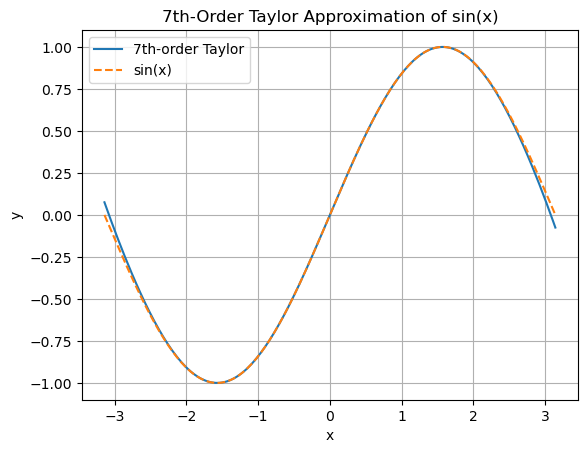

In [30]:
x = np.linspace(-np.pi, np.pi, 200)
y = np.zeros(len(x))

for n in range(4):
    y = y + ((-1)**n * x**(2*n + 1)) / math.factorial(2*n + 1)

plt.plot(x, y, label="7th-order Taylor")
plt.plot(x, np.sin(x), "--", label="sin(x)")

plt.title("7th-Order Taylor Approximation of sin(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()

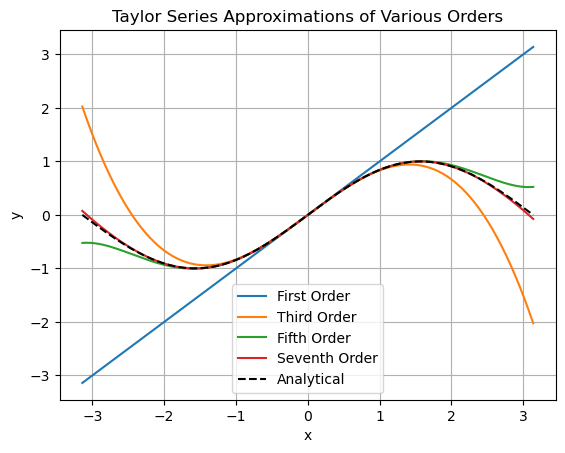

In [33]:
x = np.linspace(-np.pi, np.pi, 200)
y = np.zeros(len(x))

labels = ["First Order", "Third Order", "Fifth Order", "Seventh Order"]

for n, label in zip(range(4), labels):
    y = y + ((-1)**n * x**(2*n + 1)) / math.factorial(2*n + 1)
    plt.plot(x, y, label=label)

plt.plot(x, np.sin(x), "--", color="black" , label="Analytical")
plt.grid()
plt.title("Taylor Series Approximations of Various Orders")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [1]:
#Cos(x) Approximation Code

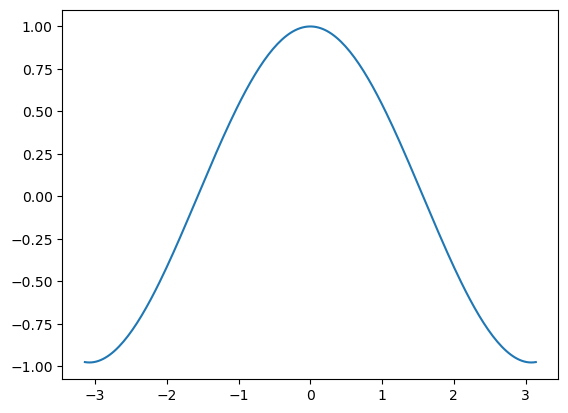

In [24]:
x = np.linspace(-np.pi, np.pi, 200) #notice how we multiplied x and y by pi :) 
y = np.zeros(len(x))

#finish the for loop
for n in range (5):  
    y = y + ((-1)**n * (x)**(2*n)) / math.factorial(2*n)

#
plt.plot(x, y)
plt.show()

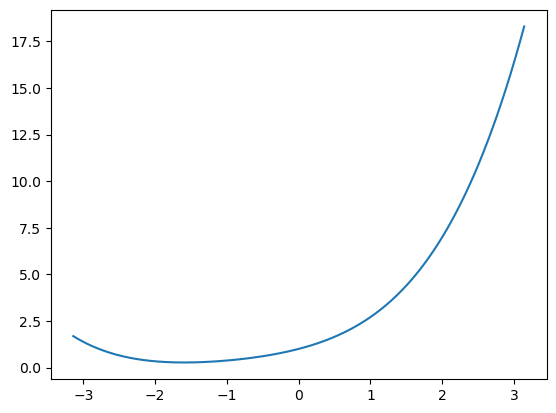

In [25]:
#e^x code
x = np.linspace(-np.pi, np.pi, 200) #notice how we multiplied x and y by pi :) 
y = np.zeros(len(x))

#finish the for loop
for n in range (5):  
    y = y + (x**n) / math.factorial(n)


plt.plot(x, y)
plt.show()

# Error
 $$Error = | \sin x - \sin_nx |$$


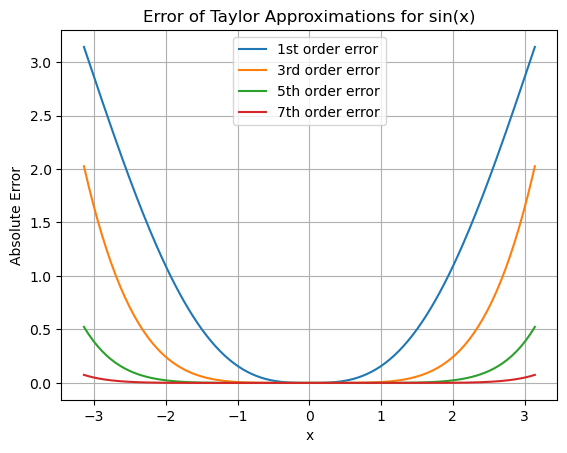

In [26]:
x = np.linspace(-np.pi, np.pi, 200)
y = np.zeros(len(x))

labels = ["1st order error", "3rd order error", "5th order error", "7th order error"]

for n, label in zip(range(4), labels):
    y = y + ((-1)**n * x**(2*n+1)) / math.factorial(2*n+1)
    error = np.abs(np.sin(x) - y)
    plt.plot(x, error, label=label)

plt.title("Error of Taylor Approximations for sin(x)")
plt.xlabel("x")
plt.ylabel("Absolute Error")
plt.grid()
plt.legend()
plt.show()

More terms leads to less error

# Problem 2
Plot Absolute Error for the taylor sereies expansion of Cos(x)

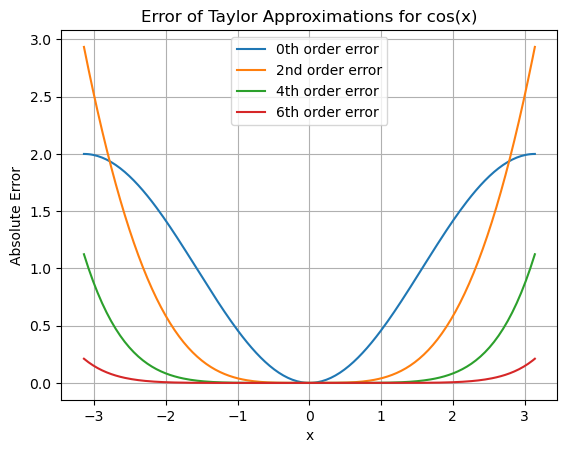

In [27]:
x = np.linspace(-np.pi, np.pi, 200)
y = np.zeros(len(x))

labels = ["0th order error", "2nd order error", "4th order error", "6th order error"]

for n, label in zip(range(4), labels):
    y = y + ((-1)**n * (x)**(2*n)) / math.factorial(2*n)
    error = np.abs(np.cos(x) - y)
    plt.plot(x, error, label=label)

plt.title("Error of Taylor Approximations for cos(x)")
plt.xlabel("x")
plt.ylabel("Absolute Error")
plt.grid()
plt.legend()
plt.show()

# Radioactive Decay Program -- Euler's Method
The behavior for radioactive decay of a large number of Uranium - 235 is governed by the differential equation: $$\frac{dN_U}{dt} = -\frac{N_U}{\tau}$$
where $\tau$ is the "time constant" for the decay. By direct subsittution the solution to this differential equation is $$N_U = N_U(0)e^{-t/\tau}$$
This is a rather simple differential equation that you will learn to solve by hand some other time. A numerical approach to this problem would be to use the Taylor expansion for $N_U$,

$$N_U(\Delta t)= N_U(0) + \frac{dN_U}{dt}\Delta t + \frac{1}{2}\frac{d^2N_U}{dt^2}(\Delta t)^2 + ...$$
It is a good enough approximation to ignore higher ordered terms so we can simplify to $$N_U(\Delta t) \approx N_U(0) + \frac{dN_U}{dt}\Delta t$$

We can change the argument from $\Delta t$ to $t + \Delta t$ so it becomes: $$N_U(t + \Delta t) \approx N_U(t) + \frac{dN_U}{dt}\Delta t $$


Notice that we dropped $(\Delta t)^2$ from approximation so the error terms are at least one factor of $\Delta t$ smaller than any of the terms in our approximation, so by making $\Delta t$ small, we can make the error terms neglible. Here we can also make the substition for the real form of the derivative of $N_U$ with respect to t from the physics of the problem: $$Nu(t + \Delta t) \approx N_U(t) - \frac{N_U(t)}{\tau}\Delta t $$

This approach is known as Euler's Method. [1]

The main ideas for this program will be to:
1. Declare necessary variables and arrays
2. Do the calculations using a for loop
3. Graph the results and compare to real analytical solution.


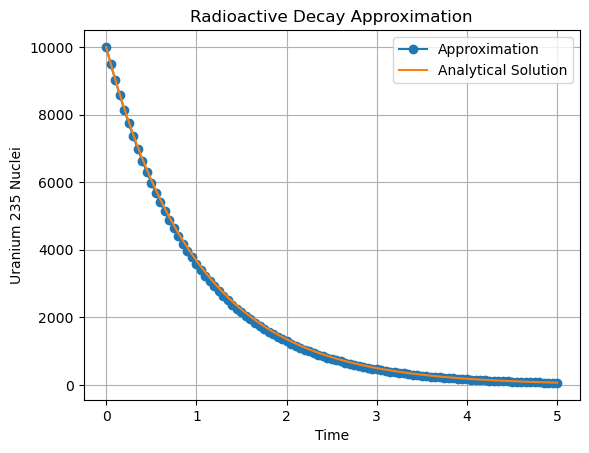

In [20]:
#Normally you want to include a few comments at the top of the program
#Written by Homero Escamilla -- June 3, 2026
#The purpose of this program is to model Radioactive Decay using Euler's Method
#Reference 1: Computational Phsyics by Nicholas J. Giordano and Hisao Nakanishi 
import numpy as np
import matplotlib.pyplot as plt

# Normally I try to define all my parameters first
U_initial = 10000   
tau = 1     
dt = 0.05   
tf = 5 

t = np.arange(0, tf + dt, dt)

#We need to store the values we generate, so we use arrays
uranium = np.zeros(len(t))
uranium[0] = U_initial

#Euler method
for i in range(len(t) - 1):
    uranium[i + 1] = uranium[i] - dt * uranium[i] / tau

#Analytical SOlution
U_exact = U_initial * np.exp(-t/tau)

plt.plot(t, uranium, "o-", label="Approximation")
plt.plot(t, U_exact, label="Analytical Solution")
plt.xlabel("Time")
plt.ylabel("Uranium 235 Nuclei")
plt.title("Radioactive Decay Approximation")
plt.legend()
plt.grid(True)
plt.show()

# Problem 3

The velocity of a freely falling object near Earth's surface is described by the equation: $$\frac{dv}{dt} = -g $$
where v is the velocity and g = 9.81 m/s^2 is the acceleration due to gravity. Write a program that employs the Euler method to compute the solution to the equation; that is, calculate $v$ as a function of $t$. For simplicity, assume that the intial velocity is zero and calculate the solution for times t=0 to t = 10s. Compare the results with the exact solution. [1]

Euler Method: $$v_{i+1} = v_i + \Delta t(-g) $$

Psuedocode:
1. Add comments to describe the program
2. Initialize variables and arrays
3. Do the calculations
4. Graph and compare

Final Velocity =  -98.0999999999999 m/s


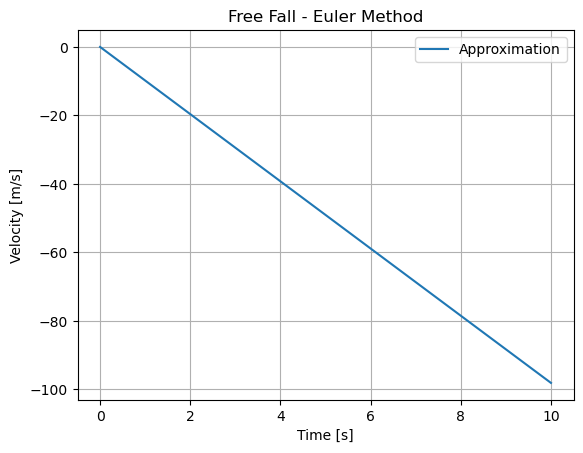

In [19]:
#Written by Homero Escamilla - June, 4 2026
#The purpose of this program is to solve the free fall equation using Euler's Method
import numpy as np
import matplotlib.pyplot as plt

#initializing variables
g = 9.81 
v0 = 0
dt = 0.1
tf = 10

t = np.arange(0, tf+dt, dt)

#Storing Values
v_array = np.zeros(len(t))
v_array[0] = v0     #technically the array is already starting as 0 but if you want different initial conidtions here you go

#Euler Method
for i in range(len(t) - 1):
    v_array[i+1] = v_array[i] + dt * (-g)

print("Final Velocity = ", v_array[len(t)-1], "m/s")
plt.plot(t, v_array, "-", label="Approximation")
plt.xlabel("Time [s]")
plt.ylabel("Velocity [m/s]")
plt.title("Free Fall - Euler Method")
plt.legend()
plt.grid(True)
plt.show()